# EDA — FreshRetailNet-50K Train Data

Dataset: `Dingdong-Inc/FreshRetailNet-50K`  
File: `data/data/train.parquet`  
Date range: 2024-03-28 → 2024-06-25 (90 days)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import ast
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid', palette='tab10')

DATA_PATH = '../data/data/train.parquet'
df = pd.read_parquet(DATA_PATH)
df['dt'] = pd.to_datetime(df['dt'])
print(f'Shape: {df.shape}')
df.head(3)

Shape: (4500000, 19)


,city_id,store_id,management_group_id,first_category_id,second_category_id,third_category_id,product_id,dt,sale_amount,hours_sale,stock_hour6_22_cnt,hours_stock_status,discount,holiday_flag,activity_flag,precpt,avg_temperature,avg_humidity,avg_wind_level
0,0,0,0,5,6,65,38,2024-03-28,0.1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.1, 0.0, ...",0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.0,0,0,1.6999,15.48,73.54,1.97
1,0,0,0,5,6,65,38,2024-03-29,0.1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.1, 0.0, 0.0, ...",1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.0,0,0,3.0190,15.08,76.56,1.71
2,0,0,0,5,6,65,38,2024-03-30,0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,"[1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.0,1,0,2.0942,15.91,76.47,1.73


## 1. Dataset Overview

In [2]:
print('=== Schema ===')
df.info(memory_usage='deep')
print()
print('=== Basic Cardinality ===')
for col in ['city_id', 'store_id', 'management_group_id',
            'first_category_id', 'second_category_id', 'third_category_id', 'product_id']:
    print(f'  {col}: {df[col].nunique()} unique values')
print(f'  dt: {df["dt"].min().date()} → {df["dt"].max().date()}  ({df["dt"].nunique()} days)')

=== Schema ===


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500000 entries, 0 to 4499999
Data columns (total 19 columns):
 #   Column               Dtype         
---  ------               -----         
 0   city_id              int64         
 1   store_id             int64         
 2   management_group_id  int64         
 3   first_category_id    int64         
 4   second_category_id   int64         
 5   third_category_id    int64         
 6   product_id           int64         
 7   dt                   datetime64[ns]
 8   sale_amount          float64       
 9   hours_sale           object        
 10  stock_hour6_22_cnt   int32         
 11  hours_stock_status   object        
 12  discount             float64       
 13  holiday_flag         int32         
 14  activity_flag        int32         
 15  precpt               float64       
 16  avg_temperature      float64       
 17  avg_humidity         float64       
 18  avg_wind_level       float64       
dtypes: datetime64[ns](1),

  first_category_id: 32 unique values
  second_category_id: 84 unique values
  third_category_id: 233 unique values


  product_id: 865 unique values
  dt: 2024-03-28 → 2024-06-25  (90 days)


In [3]:
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else 'No missing values.')

print('\n=== Descriptive Statistics (numeric) ===')
df.describe()

=== Missing Values ===


No missing values.

=== Descriptive Statistics (numeric) ===


,city_id,store_id,management_group_id,first_category_id,second_category_id,third_category_id,product_id,dt,sale_amount,stock_hour6_22_cnt,discount,holiday_flag,activity_flag,precpt,avg_temperature,avg_humidity,avg_wind_level
count,4.500000e+06,4.500000e+06,4.500000e+06,4.500000e+06,4.500000e+06,4.500000e+06,4.500000e+06,4500000,4.500000e+06,4.500000e+06,4.500000e+06,4.500000e+06,4.500000e+06,4.500000e+06,4.500000e+06,4.500000e+06,4.500000e+06
mean,4.974420e+00,4.090807e+02,4.621640e+00,1.521366e+01,4.473508e+01,1.163621e+02,3.904260e+02,2024-05-11 11:59:59.999998976,9.985913e-01,3.180341e+00,9.111412e-01,3.444444e-01,3.784207e-01,3.698385e+00,2.227911e+01,7.445046e+01,1.724542e+00
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2024-03-28 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.206000e+01,2.735000e+01,9.700000e-01
25%,0.000000e+00,1.950000e+02,3.000000e+00,5.000000e+00,2.800000e+01,7.700000e+01,1.350000e+02,2024-04-19 00:00:00,4.000000e-01,0.000000e+00,8.510000e-01,0.000000e+00,0.000000e+00,1.428800e+00,1.939000e+01,7.162000e+01,1.450000e+00
50%,0.000000e+00,3.950000e+02,6.000000e+00,1.600000e+01,3.800000e+01,1.110000e+02,3.630000e+02,2024-05-11 12:00:00,7.000000e-01,0.000000e+00,9.890000e-01,0.000000e+00,0.000000e+00,2.297700e+00,2.250000e+01,7.636000e+01,1.640000e+00
75%,1.200000e+01,5.980000e+02,6.000000e+00,2.100000e+01,6.600000e+01,1.670000e+02,6.330000e+02,2024-06-03 00:00:00,1.100000e+00,6.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,4.481600e+00,2.540000e+01,8.071000e+01,1.950000e+00
max,1.700000e+01,8.970000e+02,6.000000e+00,3.100000e+01,8.300000e+01,2.320000e+02,8.640000e+02,2024-06-25 00:00:00,4.490000e+01,1.600000e+01,1.088000e+00,1.000000e+00,1.000000e+00,4.250000e+01,3.088000e+01,1.000000e+02,3.850000e+00
std,6.096600e+00,2.485456e+02,1.962418e+00,8.972127e+00,2.233890e+01,5.756037e+01,2.634697e+02,NaN,1.406738e+00,4.596586e+00,1.281734e-01,4.751868e-01,4.849933e-01,3.683960e+00,3.593264e+00,1.009831e+01,3.845731e-01


## 2. Target Variable — `sale_amount`

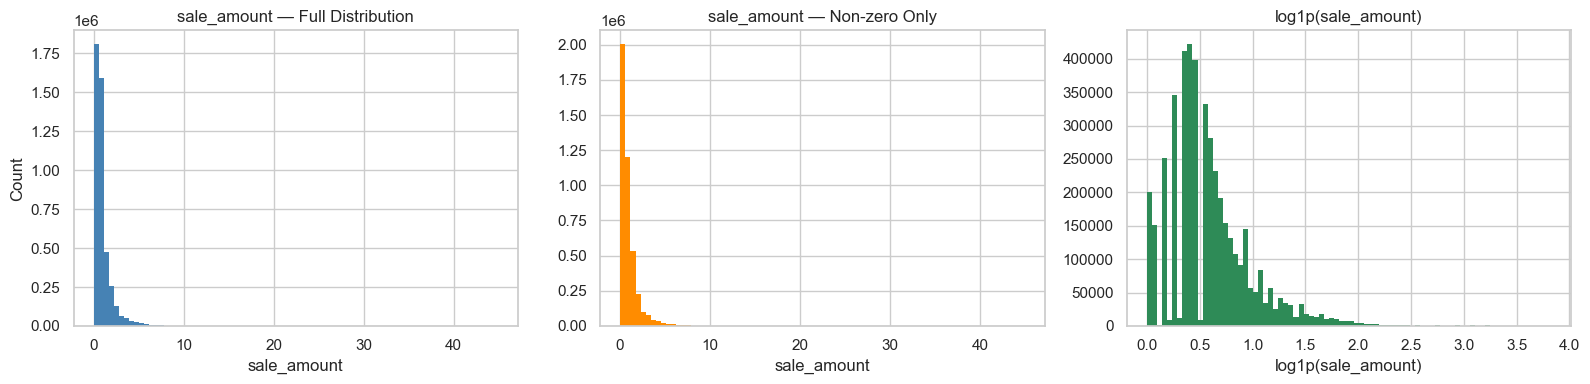

Zero-sale records: 4.46%
Non-zero sale stats:
count    4.299240e+06
mean     1.045222e+00
std      1.422174e+00
min      6.000000e-02
25%      4.000000e-01
50%      7.000000e-01
75%      1.200000e+00
max      4.490000e+01
Name: sale_amount, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribution (all values)
axes[0].hist(df['sale_amount'], bins=80, color='steelblue', edgecolor='none')
axes[0].set_title('sale_amount — Full Distribution')
axes[0].set_xlabel('sale_amount')
axes[0].set_ylabel('Count')

# Distribution (non-zero)
nz = df[df['sale_amount'] > 0]['sale_amount']
axes[1].hist(nz, bins=80, color='darkorange', edgecolor='none')
axes[1].set_title('sale_amount — Non-zero Only')
axes[1].set_xlabel('sale_amount')

# Log scale
axes[2].hist(np.log1p(df['sale_amount']), bins=80, color='seagreen', edgecolor='none')
axes[2].set_title('log1p(sale_amount)')
axes[2].set_xlabel('log1p(sale_amount)')

plt.tight_layout()
plt.show()

zero_pct = (df['sale_amount'] == 0).mean() * 100
print(f'Zero-sale records: {zero_pct:.2f}%')
print(f'Non-zero sale stats:\n{nz.describe()}')

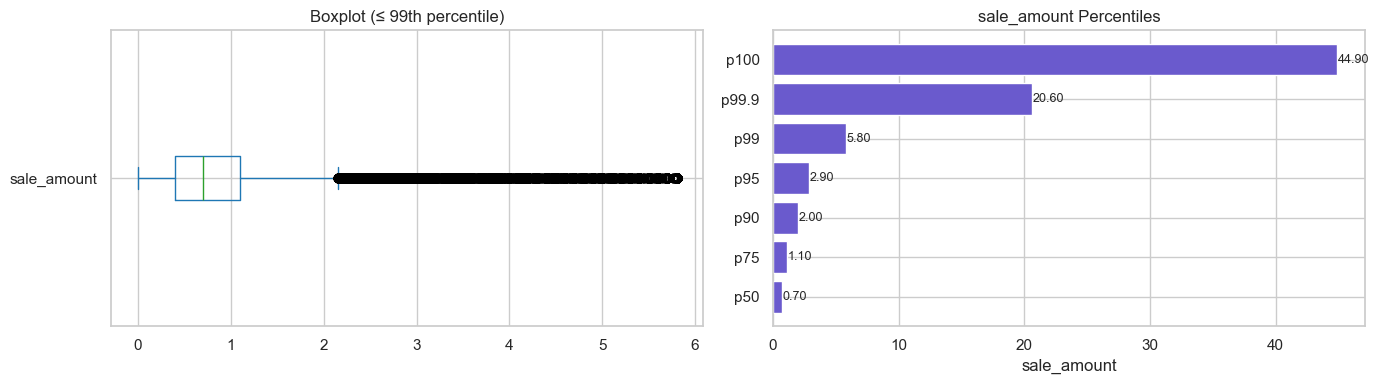

In [5]:
# Boxplot + outlier check
q99 = df['sale_amount'].quantile(0.99)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df[df['sale_amount'] <= q99]['sale_amount'].plot.box(ax=axes[0], vert=False)
axes[0].set_title('Boxplot (≤ 99th percentile)')

# Percentile table
pcts = [50, 75, 90, 95, 99, 99.9, 100]
vals = np.percentile(df['sale_amount'], pcts)
axes[1].barh([f'p{p}' for p in pcts], vals, color='slateblue')
axes[1].set_title('sale_amount Percentiles')
axes[1].set_xlabel('sale_amount')
for i, v in enumerate(vals):
    axes[1].text(v + 0.05, i, f'{v:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 3. Time Series — Aggregated Daily Sales

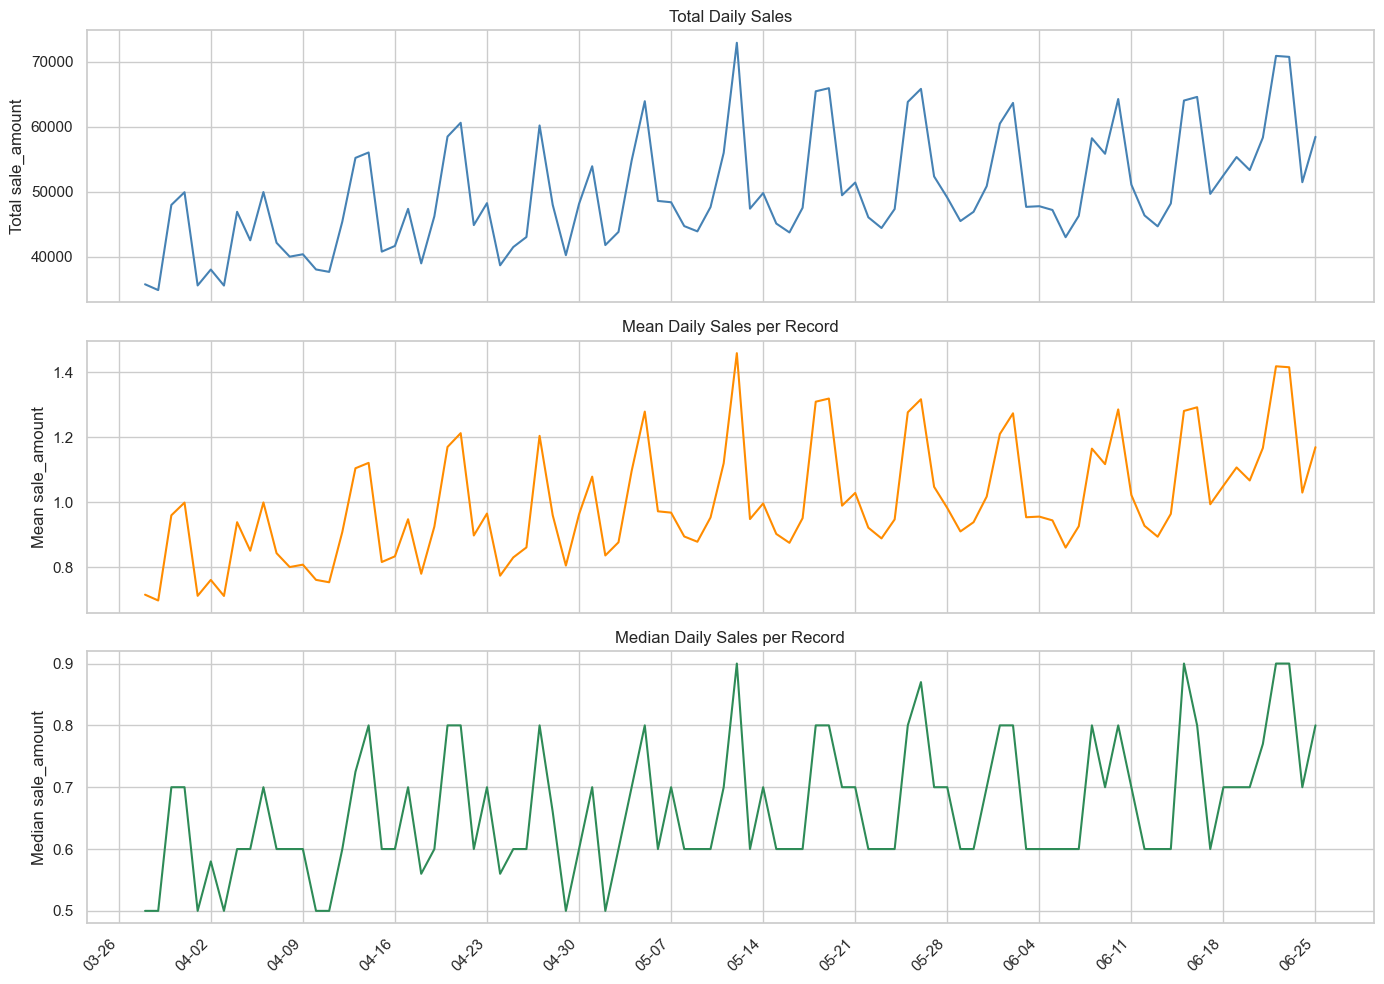

In [6]:
daily = df.groupby('dt')['sale_amount'].agg(['sum', 'mean', 'median']).reset_index()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(daily['dt'], daily['sum'], color='steelblue', lw=1.5)
axes[0].set_title('Total Daily Sales')
axes[0].set_ylabel('Total sale_amount')

axes[1].plot(daily['dt'], daily['mean'], color='darkorange', lw=1.5)
axes[1].set_title('Mean Daily Sales per Record')
axes[1].set_ylabel('Mean sale_amount')

axes[2].plot(daily['dt'], daily['median'], color='seagreen', lw=1.5)
axes[2].set_title('Median Daily Sales per Record')
axes[2].set_ylabel('Median sale_amount')

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

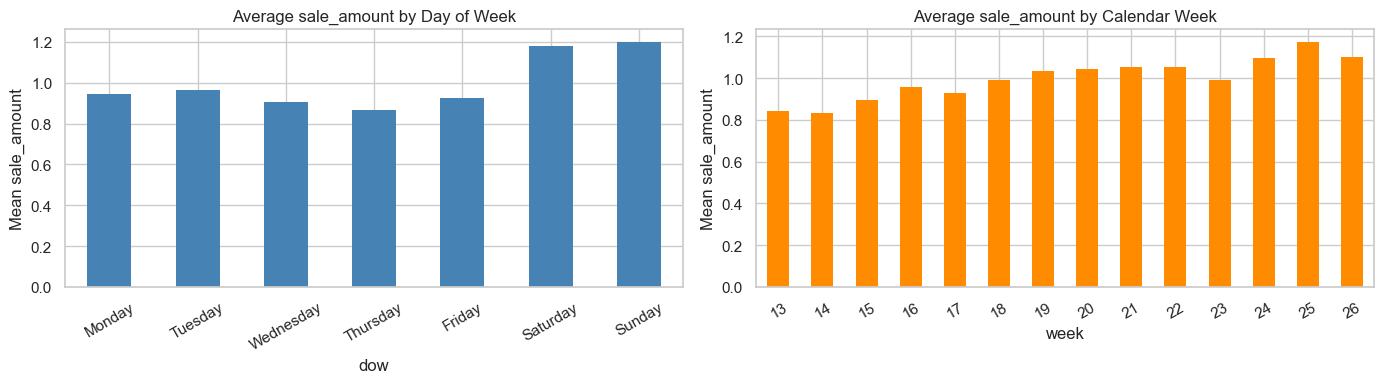

In [7]:
# Day-of-week pattern
df['dow'] = df['dt'].dt.day_name()
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_avg = df.groupby('dow')['sale_amount'].mean().reindex(dow_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
dow_avg.plot.bar(ax=axes[0], color='steelblue', edgecolor='none')
axes[0].set_title('Average sale_amount by Day of Week')
axes[0].set_ylabel('Mean sale_amount')
axes[0].tick_params(axis='x', rotation=30)

# Monthly / week-of-study pattern
df['week'] = df['dt'].dt.isocalendar().week.astype(int)
week_avg = df.groupby('week')['sale_amount'].mean()
week_avg.plot.bar(ax=axes[1], color='darkorange', edgecolor='none')
axes[1].set_title('Average sale_amount by Calendar Week')
axes[1].set_ylabel('Mean sale_amount')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 4. Hourly Sales Pattern

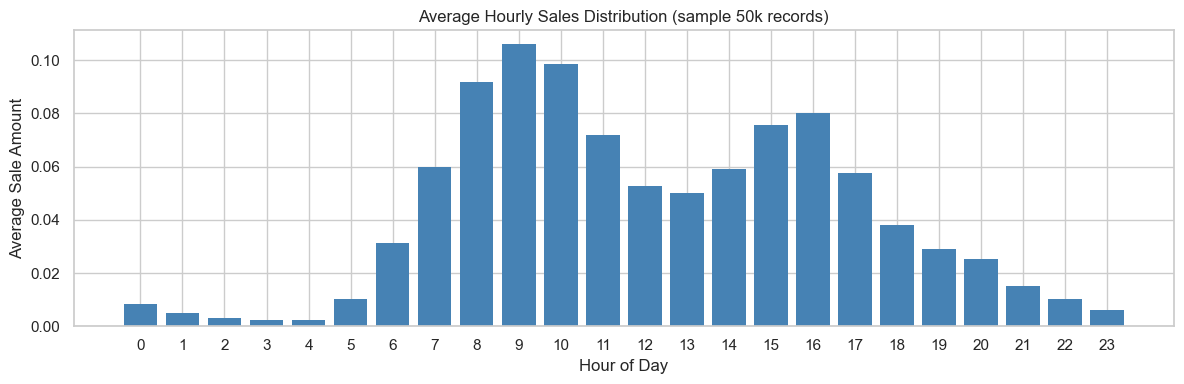

In [8]:
# Parse hours_sale (stored as string list) and compute hourly averages
sample = df.sample(min(50_000, len(df)), random_state=42).copy()
sample['hours_sale_parsed'] = sample['hours_sale'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
hourly_matrix = pd.DataFrame(sample['hours_sale_parsed'].tolist(), columns=[f'h{i}' for i in range(24)])
hourly_mean = hourly_matrix.mean()

plt.figure(figsize=(12, 4))
plt.bar(range(24), hourly_mean.values, color='steelblue', edgecolor='none')
plt.xticks(range(24))
plt.xlabel('Hour of Day')
plt.ylabel('Average Sale Amount')
plt.title('Average Hourly Sales Distribution (sample 50k records)')
plt.tight_layout()
plt.show()

## 5. Entity Distribution — City, Store, Product, Category

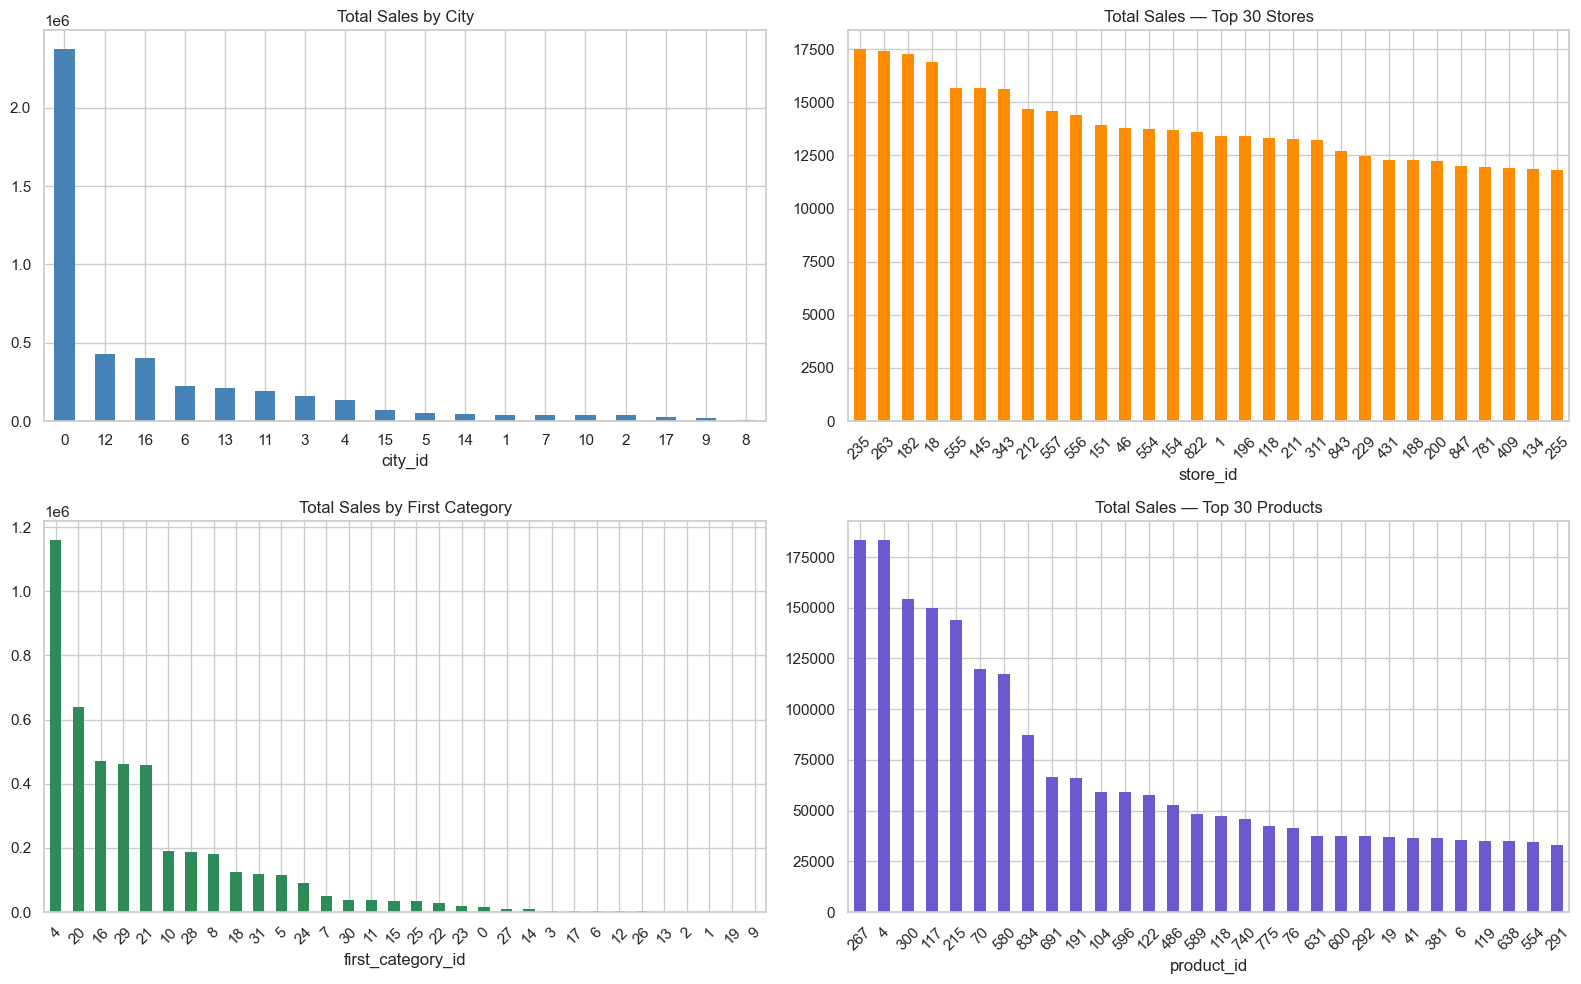

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# City
city_sales = df.groupby('city_id')['sale_amount'].sum().sort_values(ascending=False)
city_sales.plot.bar(ax=axes[0, 0], color='steelblue', edgecolor='none')
axes[0, 0].set_title('Total Sales by City')
axes[0, 0].set_xlabel('city_id')
axes[0, 0].tick_params(axis='x', rotation=0)

# Store (top 30)
store_sales = df.groupby('store_id')['sale_amount'].sum().sort_values(ascending=False).head(30)
store_sales.plot.bar(ax=axes[0, 1], color='darkorange', edgecolor='none')
axes[0, 1].set_title('Total Sales — Top 30 Stores')
axes[0, 1].set_xlabel('store_id')
axes[0, 1].tick_params(axis='x', rotation=45)

# First category
cat1_sales = df.groupby('first_category_id')['sale_amount'].sum().sort_values(ascending=False)
cat1_sales.plot.bar(ax=axes[1, 0], color='seagreen', edgecolor='none')
axes[1, 0].set_title('Total Sales by First Category')
axes[1, 0].set_xlabel('first_category_id')
axes[1, 0].tick_params(axis='x', rotation=45)

# Product (top 30)
prod_sales = df.groupby('product_id')['sale_amount'].sum().sort_values(ascending=False).head(30)
prod_sales.plot.bar(ax=axes[1, 1], color='slateblue', edgecolor='none')
axes[1, 1].set_title('Total Sales — Top 30 Products')
axes[1, 1].set_xlabel('product_id')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

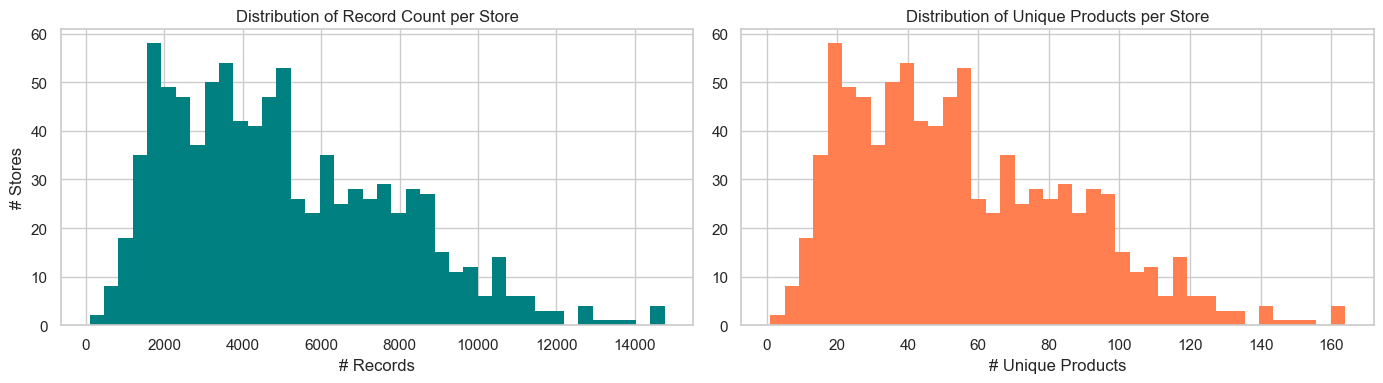

Avg records per store: 5011
Avg products per store: 55.7


In [10]:
# Records per store (data coverage)
records_per_store = df.groupby('store_id').size()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(records_per_store, bins=40, color='teal', edgecolor='none')
axes[0].set_title('Distribution of Record Count per Store')
axes[0].set_xlabel('# Records')
axes[0].set_ylabel('# Stores')

# products per store
prods_per_store = df.groupby('store_id')['product_id'].nunique()
axes[1].hist(prods_per_store, bins=40, color='coral', edgecolor='none')
axes[1].set_title('Distribution of Unique Products per Store')
axes[1].set_xlabel('# Unique Products')

plt.tight_layout()
plt.show()

print(f'Avg records per store: {records_per_store.mean():.0f}')
print(f'Avg products per store: {prods_per_store.mean():.1f}')

## 6. Weather Features

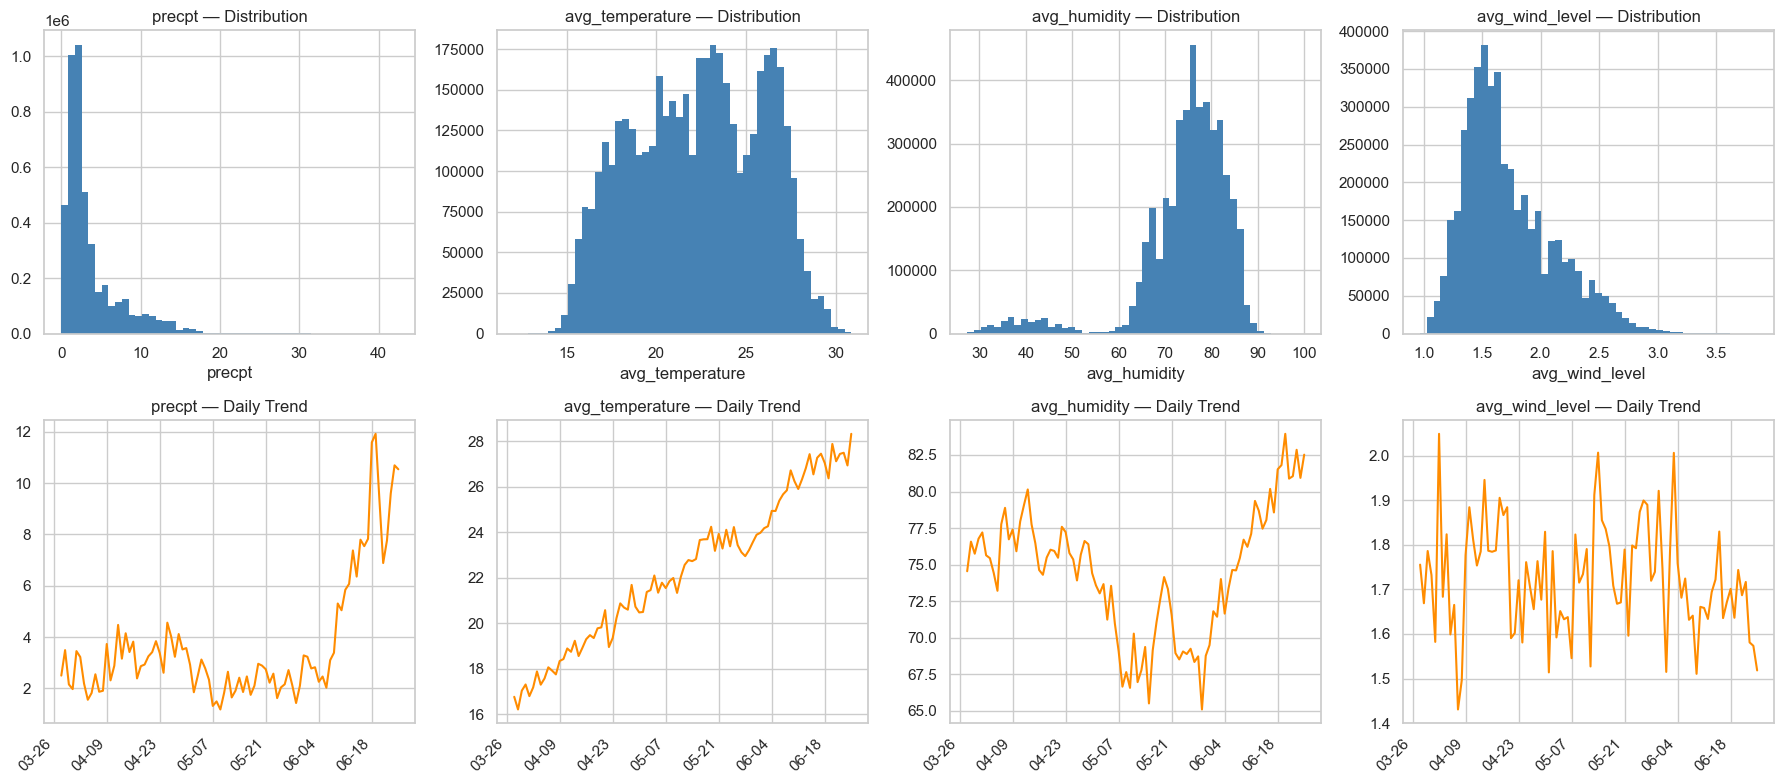

In [11]:
weather_cols = ['precpt', 'avg_temperature', 'avg_humidity', 'avg_wind_level']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, col in enumerate(weather_cols):
    # Distribution
    axes[0, i].hist(df[col], bins=50, color='steelblue', edgecolor='none')
    axes[0, i].set_title(f'{col} — Distribution')
    axes[0, i].set_xlabel(col)

    # Time trend (daily mean)
    trend = df.groupby('dt')[col].mean()
    axes[1, i].plot(trend.index, trend.values, lw=1.5, color='darkorange')
    axes[1, i].set_title(f'{col} — Daily Trend')
    axes[1, i].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    axes[1, i].xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.setp(axes[1, i].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

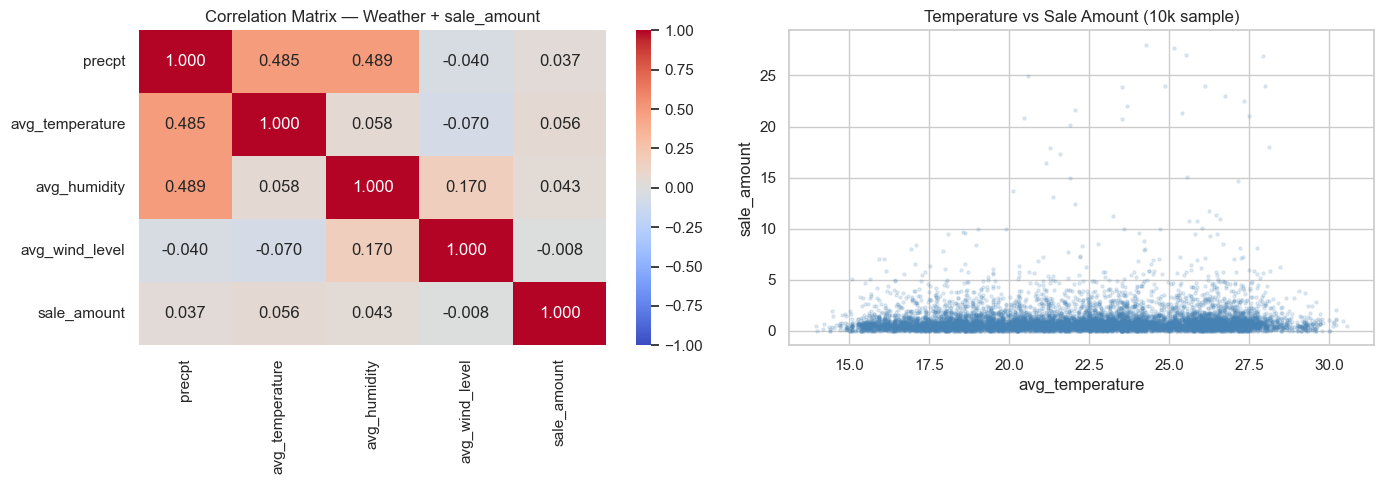

In [12]:
# Correlation between weather and sales
weather_sale = df[weather_cols + ['sale_amount']].copy()
corr = weather_sale.corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Correlation Matrix — Weather + sale_amount')

# Scatter: temperature vs sale_amount (sample)
s = df.sample(10_000, random_state=0)
axes[1].scatter(s['avg_temperature'], s['sale_amount'], alpha=0.15, s=5, color='steelblue')
axes[1].set_xlabel('avg_temperature')
axes[1].set_ylabel('sale_amount')
axes[1].set_title('Temperature vs Sale Amount (10k sample)')

plt.tight_layout()
plt.show()

## 7. Holiday & Activity Flags

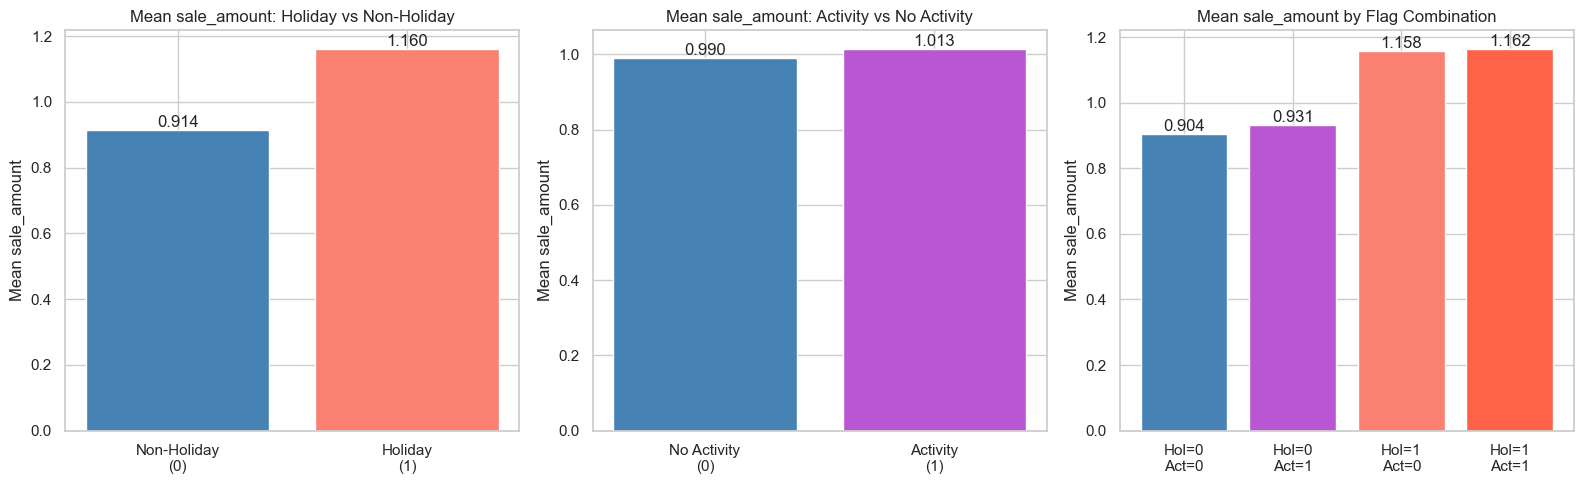

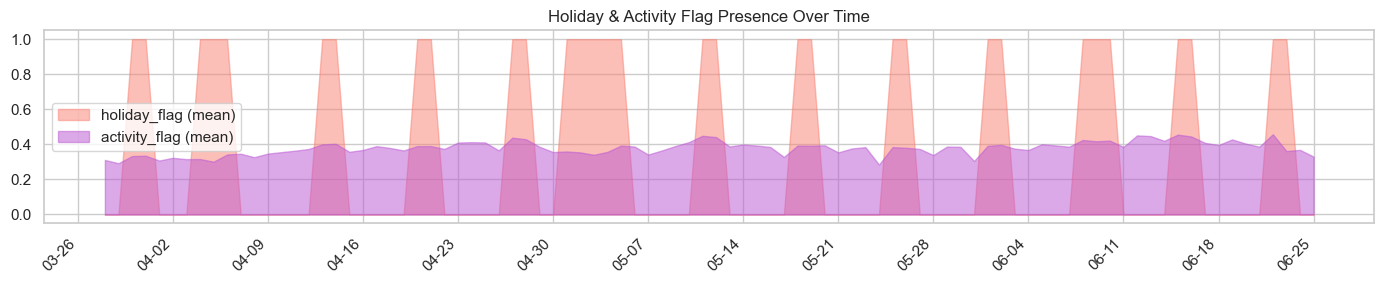

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# holiday_flag
hol = df.groupby('holiday_flag')['sale_amount'].mean()
axes[0].bar(['Non-Holiday\n(0)', 'Holiday\n(1)'], hol.values, color=['steelblue', 'salmon'])
axes[0].set_title('Mean sale_amount: Holiday vs Non-Holiday')
axes[0].set_ylabel('Mean sale_amount')
for i, v in enumerate(hol.values):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center')

# activity_flag
act = df.groupby('activity_flag')['sale_amount'].mean()
axes[1].bar(['No Activity\n(0)', 'Activity\n(1)'], act.values, color=['steelblue', 'mediumorchid'])
axes[1].set_title('Mean sale_amount: Activity vs No Activity')
axes[1].set_ylabel('Mean sale_amount')
for i, v in enumerate(act.values):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center')

# Combined
combo = df.groupby(['holiday_flag', 'activity_flag'])['sale_amount'].mean().reset_index()
combo['label'] = combo.apply(lambda r: f'Hol={int(r.holiday_flag)}\nAct={int(r.activity_flag)}', axis=1)
axes[2].bar(combo['label'], combo['sale_amount'],
            color=['steelblue', 'mediumorchid', 'salmon', 'tomato'])
axes[2].set_title('Mean sale_amount by Flag Combination')
axes[2].set_ylabel('Mean sale_amount')
for i, v in enumerate(combo['sale_amount']):
    axes[2].text(i, v + 0.01, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.show()

# Timeline of flags
daily_flags = df.groupby('dt')[['holiday_flag', 'activity_flag']].mean()
fig, ax = plt.subplots(figsize=(14, 3))
ax.fill_between(daily_flags.index, daily_flags['holiday_flag'], alpha=0.5, label='holiday_flag (mean)', color='salmon')
ax.fill_between(daily_flags.index, daily_flags['activity_flag'], alpha=0.5, label='activity_flag (mean)', color='mediumorchid')
ax.set_title('Holiday & Activity Flag Presence Over Time')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Discount Analysis

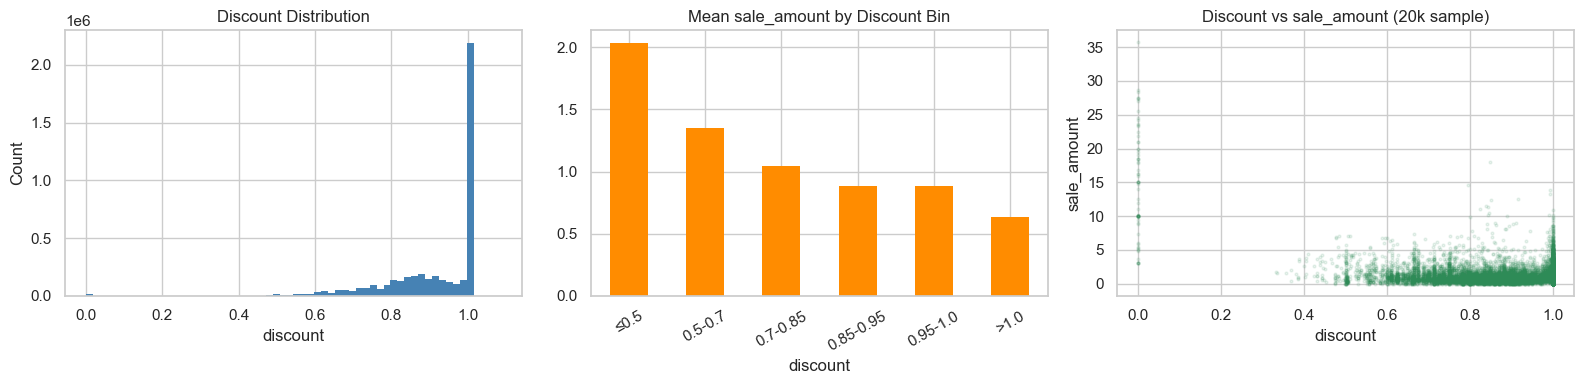

Proportion at full price (discount=1.0): 48.5%
Proportion with discount < 1.0: 51.5%


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribution
axes[0].hist(df['discount'], bins=60, color='steelblue', edgecolor='none')
axes[0].set_title('Discount Distribution')
axes[0].set_xlabel('discount')
axes[0].set_ylabel('Count')

# Discount bins vs sale_amount
df['discount_bin'] = pd.cut(df['discount'], bins=[0, 0.5, 0.7, 0.85, 0.95, 1.0, 1.1],
                             labels=['≤0.5', '0.5-0.7', '0.7-0.85', '0.85-0.95', '0.95-1.0', '>1.0'])
disc_sale = df.groupby('discount_bin', observed=True)['sale_amount'].mean()
disc_sale.plot.bar(ax=axes[1], color='darkorange', edgecolor='none')
axes[1].set_title('Mean sale_amount by Discount Bin')
axes[1].set_xlabel('discount')
axes[1].tick_params(axis='x', rotation=30)

# Scatter sample
s = df.sample(20_000, random_state=1)
axes[2].scatter(s['discount'], s['sale_amount'], alpha=0.1, s=4, color='seagreen')
axes[2].set_xlabel('discount')
axes[2].set_ylabel('sale_amount')
axes[2].set_title('Discount vs sale_amount (20k sample)')

plt.tight_layout()
plt.show()

print(f'Proportion at full price (discount=1.0): {(df["discount"]==1.0).mean()*100:.1f}%')
print(f'Proportion with discount < 1.0: {(df["discount"] < 1.0).mean()*100:.1f}%')

## 9. Stock Status Analysis

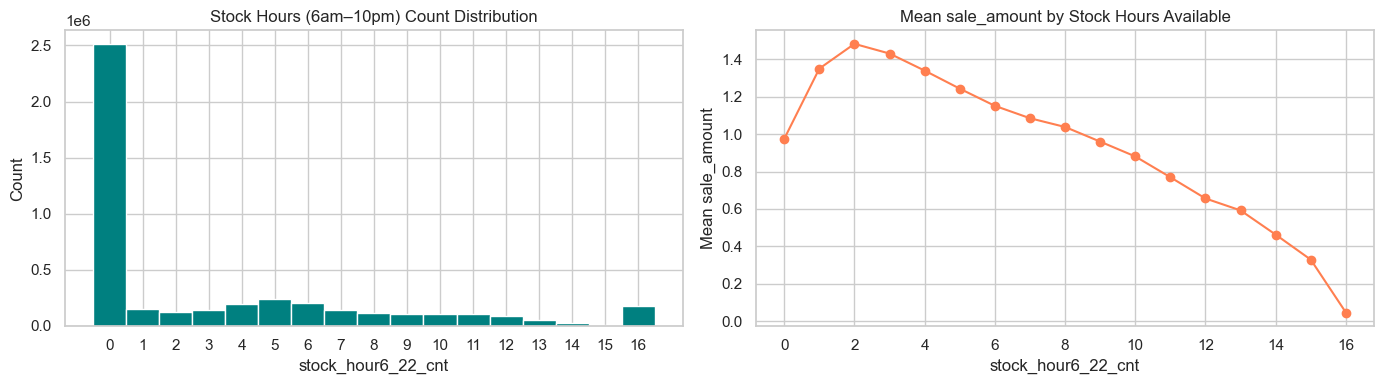

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# stock_hour6_22_cnt distribution
axes[0].hist(df['stock_hour6_22_cnt'], bins=range(0, 18), color='teal', edgecolor='white', align='left')
axes[0].set_title('Stock Hours (6am–10pm) Count Distribution')
axes[0].set_xlabel('stock_hour6_22_cnt')
axes[0].set_ylabel('Count')
axes[0].set_xticks(range(0, 17))

# stock_hour6_22_cnt vs sale_amount
stock_sale = df.groupby('stock_hour6_22_cnt')['sale_amount'].mean()
stock_sale.plot(ax=axes[1], marker='o', color='coral')
axes[1].set_title('Mean sale_amount by Stock Hours Available')
axes[1].set_xlabel('stock_hour6_22_cnt')
axes[1].set_ylabel('Mean sale_amount')

plt.tight_layout()
plt.show()

## 10. Full Feature Correlation

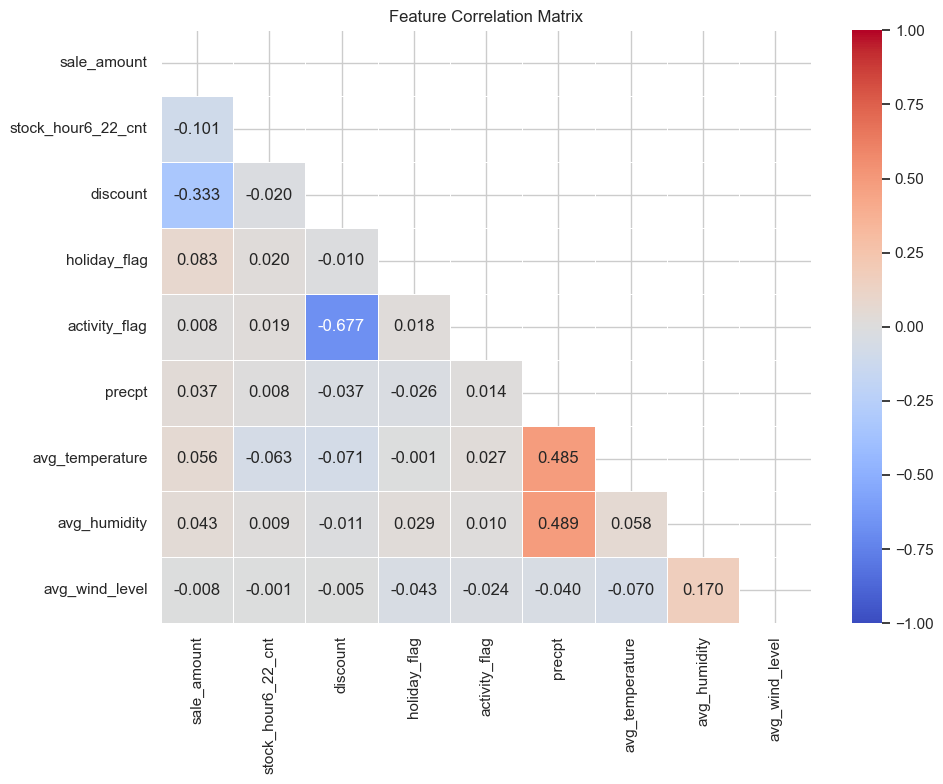

In [16]:
num_cols = ['sale_amount', 'stock_hour6_22_cnt', 'discount',
            'holiday_flag', 'activity_flag',
            'precpt', 'avg_temperature', 'avg_humidity', 'avg_wind_level']
corr_full = df[num_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_full, dtype=bool))
sns.heatmap(corr_full, mask=mask, annot=True, fmt='.3f',
            cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 11. Top Products — Time Series Trends

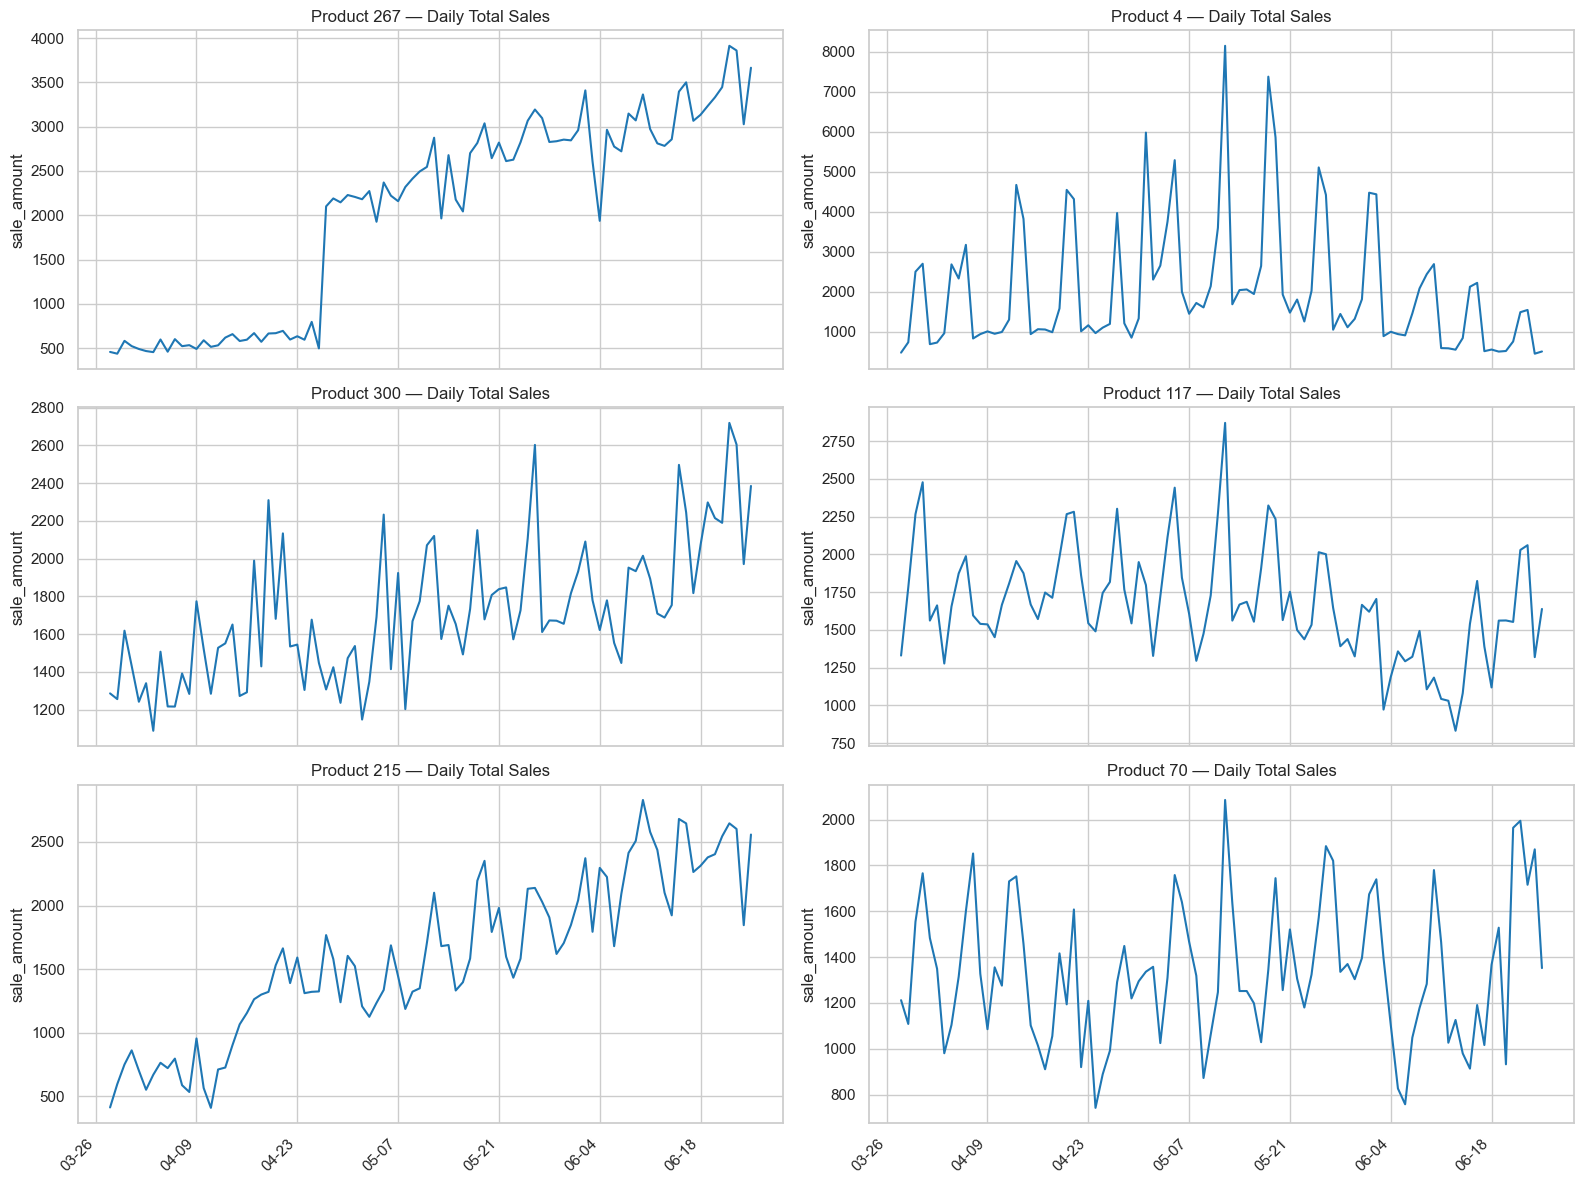

In [17]:
top_products = df.groupby('product_id')['sale_amount'].sum().nlargest(6).index.tolist()

fig, axes = plt.subplots(3, 2, figsize=(16, 12), sharex=True)
axes = axes.flatten()

for i, pid in enumerate(top_products):
    prod_daily = df[df['product_id'] == pid].groupby('dt')['sale_amount'].sum()
    axes[i].plot(prod_daily.index, prod_daily.values, lw=1.5)
    axes[i].set_title(f'Product {pid} — Daily Total Sales')
    axes[i].set_ylabel('sale_amount')
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    axes[i].xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.setp(axes[i].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

## 12. Summary

In [18]:
summary = {
    'Total records': len(df),
    'Date range': f'{df["dt"].min().date()} → {df["dt"].max().date()}',
    'Number of days': df['dt'].nunique(),
    'Cities': df['city_id'].nunique(),
    'Stores': df['store_id'].nunique(),
    'Products': df['product_id'].nunique(),
    'First categories': df['first_category_id'].nunique(),
    'Zero-sale records (%)': f'{(df["sale_amount"] == 0).mean()*100:.2f}%',
    'Mean sale_amount (non-zero)': f'{df[df["sale_amount"]>0]["sale_amount"].mean():.4f}',
    'Max sale_amount': df['sale_amount'].max(),
    'Holiday days (%)': f'{df["holiday_flag"].mean()*100:.1f}%',
    'Activity days (%)': f'{df["activity_flag"].mean()*100:.1f}%',
    'Avg temperature range': f'{df["avg_temperature"].min():.1f} – {df["avg_temperature"].max():.1f} °C',
}

print('=== EDA Summary ===')
for k, v in summary.items():
    print(f'  {k}: {v}')

=== EDA Summary ===
  Total records: 4500000
  Date range: 2024-03-28 → 2024-06-25
  Number of days: 90
  Cities: 18
  Stores: 898
  Products: 865
  First categories: 32
  Zero-sale records (%): 4.46%
  Mean sale_amount (non-zero): 1.0452
  Max sale_amount: 44.9
  Holiday days (%): 34.4%
  Activity days (%): 37.8%
  Avg temperature range: 12.1 – 30.9 °C
